In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
import pandas as pd
%matplotlib inline

In [2]:
# Read in all soil data for all stations

soil_list = []

for i in range (1, 7) :
    
    df_soil = pd.read_csv('../datasets/TX-Data/soil_station/SM_' + str(i) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")

    # pandas remove spaces in the column names
    df_soil.columns = df_soil.columns.str.replace(' ','')
    df_soil['SWC_5'] = df_soil['SWC_5'].astype(float)
    df_soil['SWC_10'] = df_soil['SWC_10'].astype(float)
    df_soil['SWC_20'] = df_soil['SWC_20'].astype(float)
    df_soil['SWC_50'] = df_soil['SWC_50'].astype(float)

    df_soil['T_5'] = df_soil['T_5'].astype(float)
    df_soil['T_10'] = df_soil['T_10'].astype(float)
    df_soil['T_20'] = df_soil['T_20'].astype(float)
    df_soil['T_50'] = df_soil['T_50'].astype(float)

    df_soil['Ppt'] = df_soil['Ppt'].astype(float)
    
    # add station's soil data to list
    soil_list.append(df_soil)

len(soil_list)

6

These are the data ranges for the raw soil data for all the stations:

- Station 1: 2015-01-01 to 2021-10-01
- Station 2: 2015-01-01 to 2021-06-06 13:00:00
- Station 3: 2015-01-01 to 2021-10-01 
- Station 4: 2015-01-01 to 2021-10-01 (two NaN columns)
- Station 5: 2015-01-01 to 2021-10-01 (kind of one NaN columns)
- Station 6: 2015-01-01 to 2021-10-01

In [3]:
#remove extraneous NaN rows from station 2 soil data
station_2 = soil_list[1].loc[:'2021-06-06 13:00:00']
soil_list[1] = station_2

In [4]:
# Read in all met data for all stations

met_list = []

for i in range(1, 7) :

    df_met = pd.read_csv('../datasets/TX-Data/met_station/MET_' + str(i) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")

    # pandas remove spaces in the column names
    df_met.columns = df_met.columns.str.replace(' ','')
    df_met['Ppt'] = df_met['Ppt'].astype(float)
    df_met['Tair'] = df_met['Tair'].astype(float)
    df_met['RH'] = df_met['RH'].astype(float)
    df_met['Windspeed'] = df_met['Windspeed'].astype(float)
    df_met['Winddirection'] = df_met['Winddirection'].astype(float)
    df_met['Srad'] = df_met['Srad'].astype(float)
    
    # add station's met data to list
    met_list.append(df_met)
    
len(met_list)

6

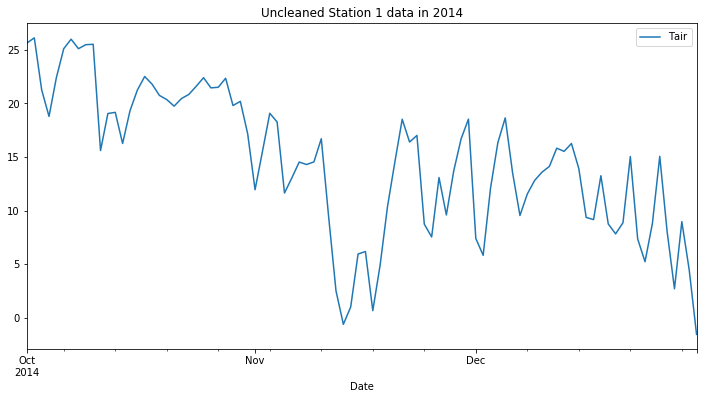

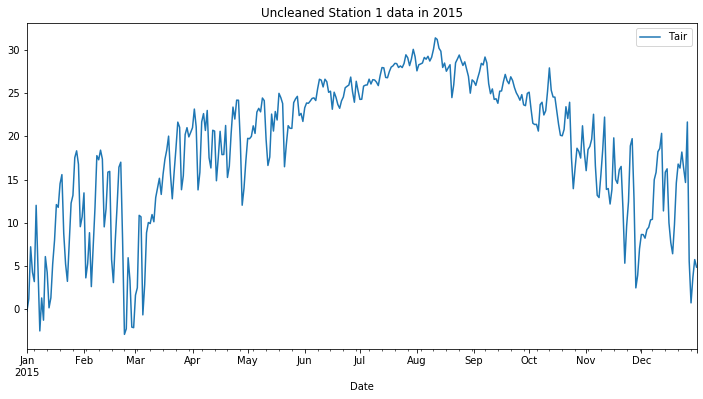

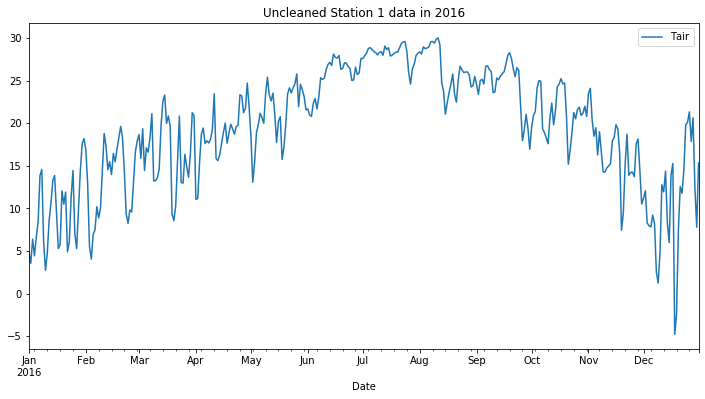

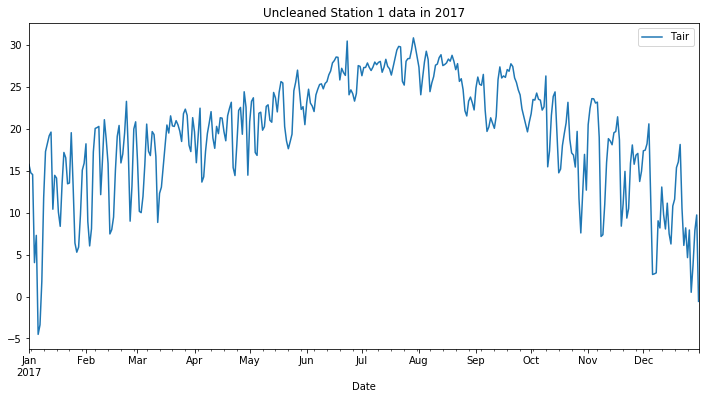

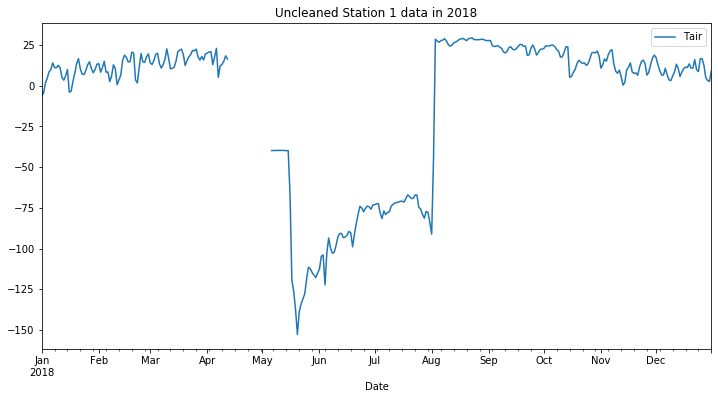

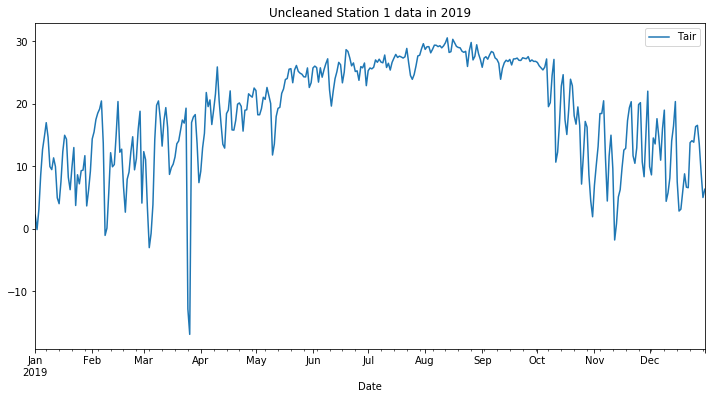

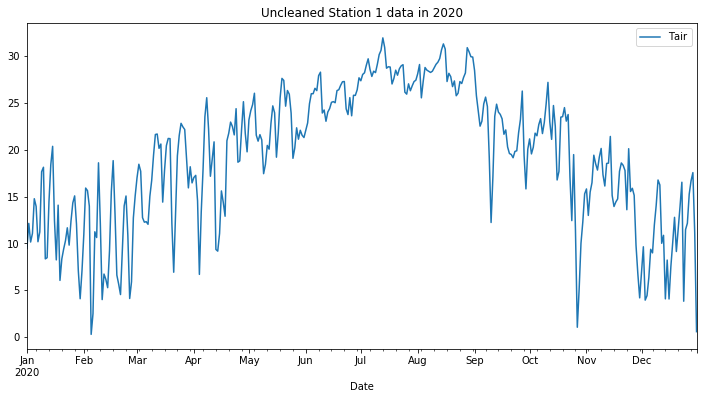

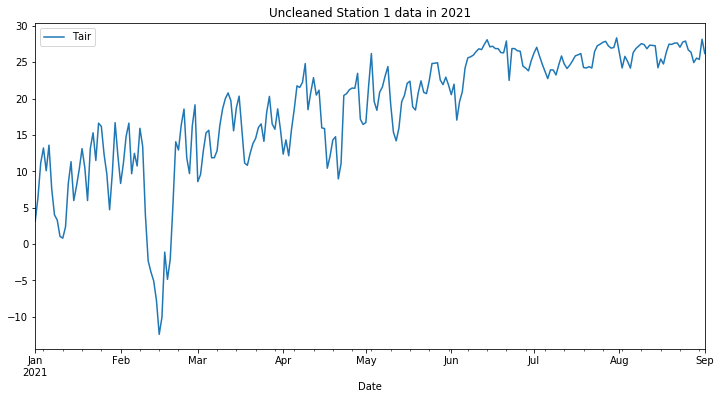

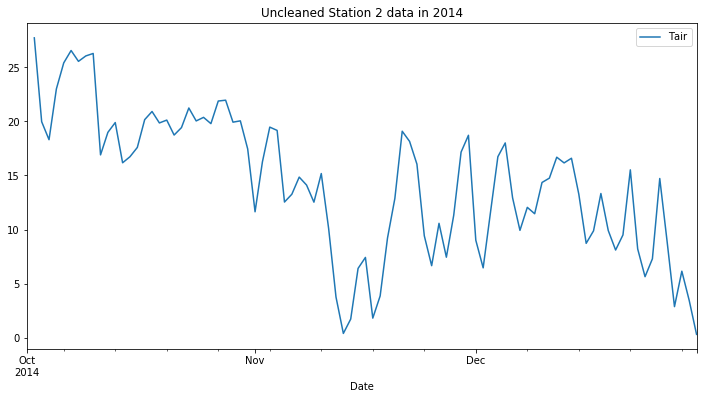

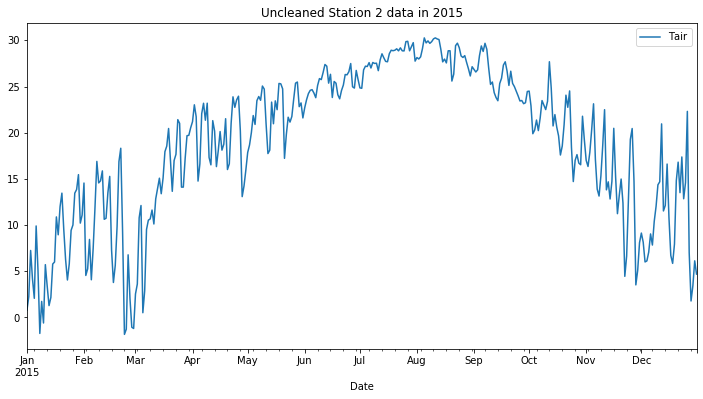

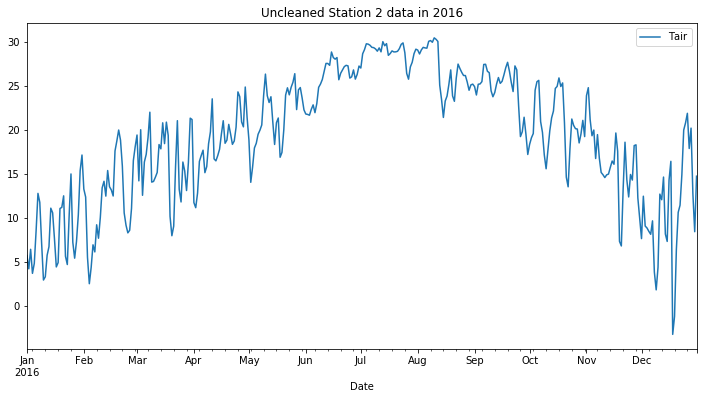

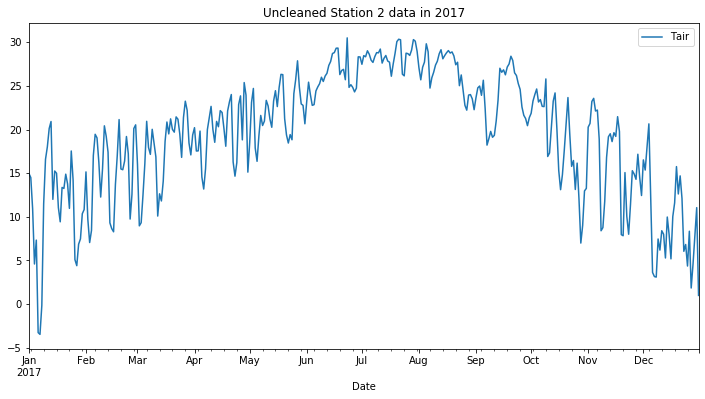

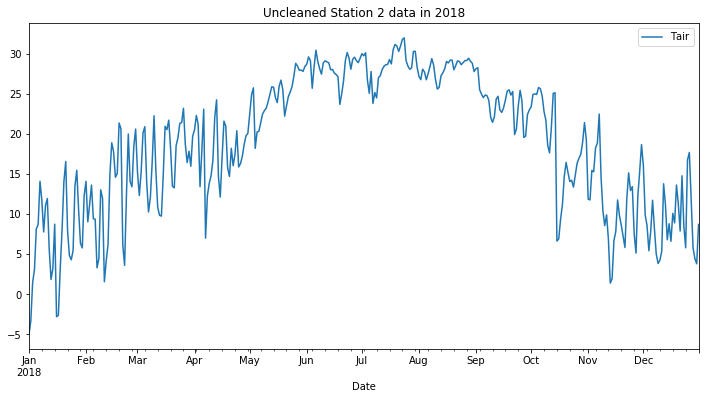

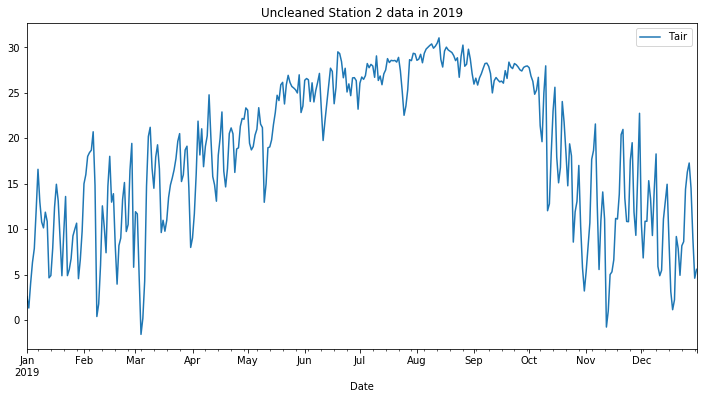

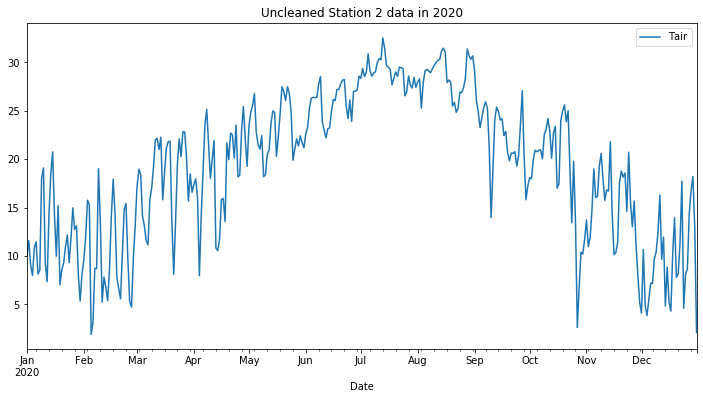

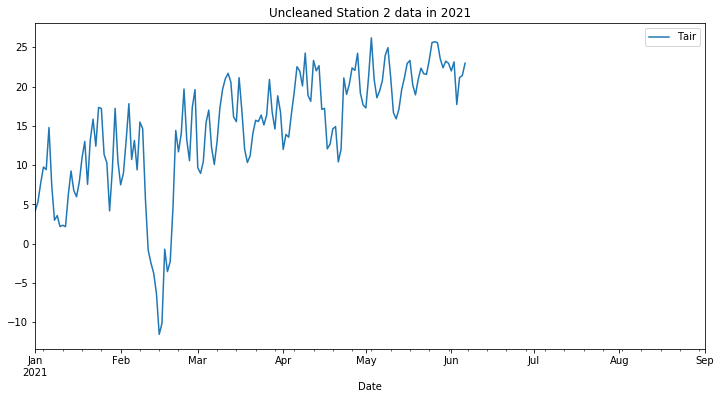

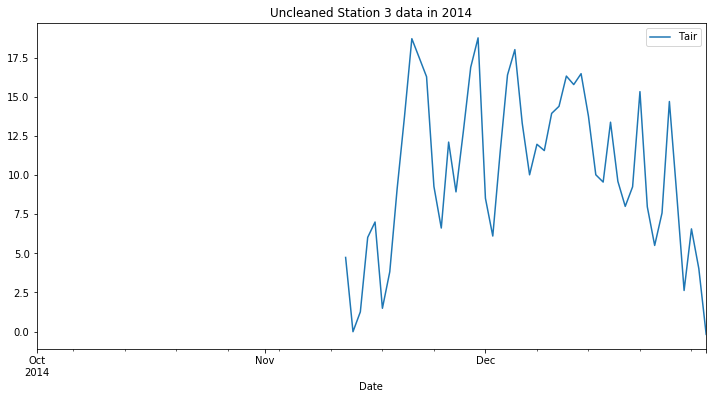

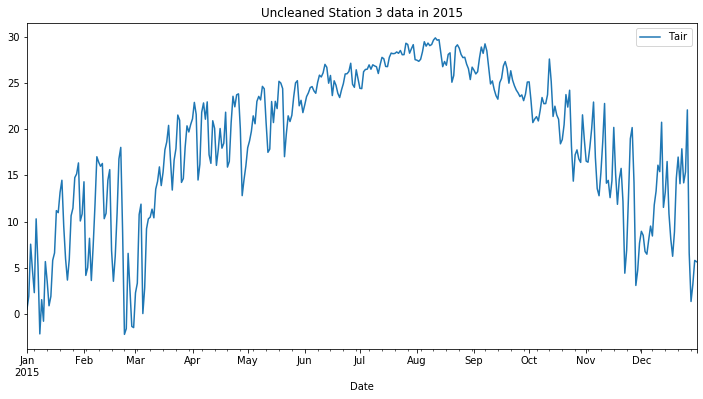

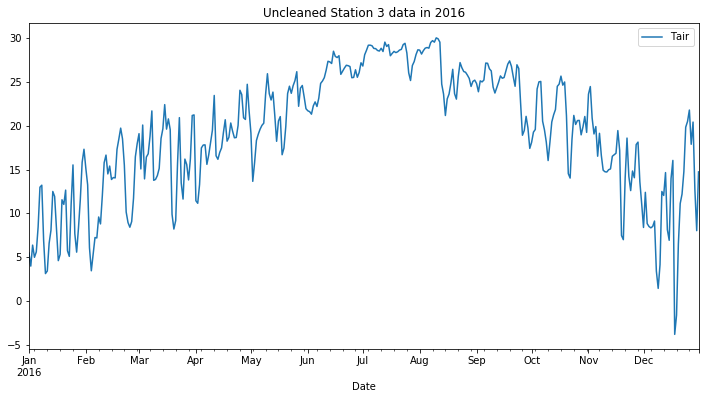

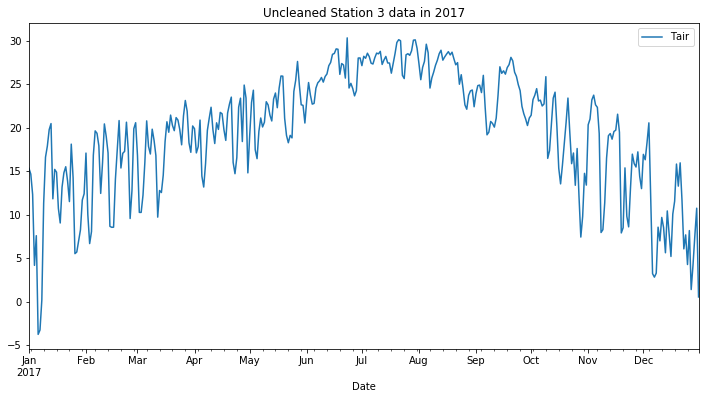

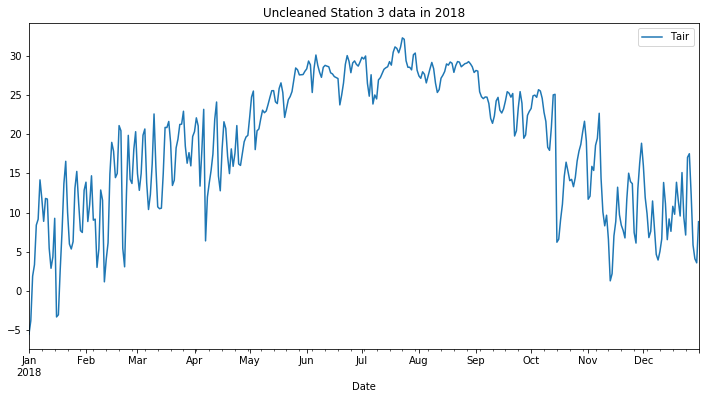

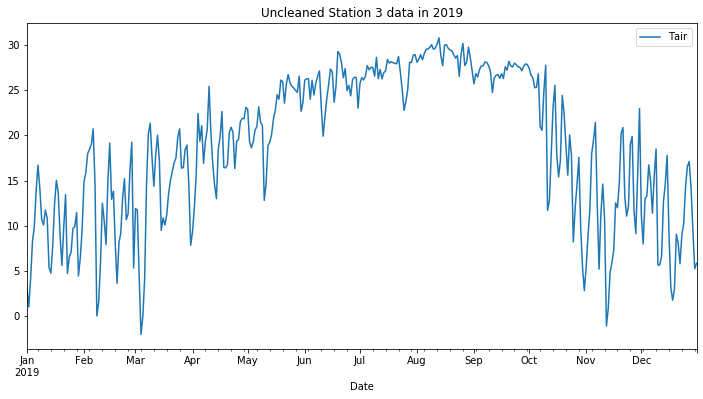

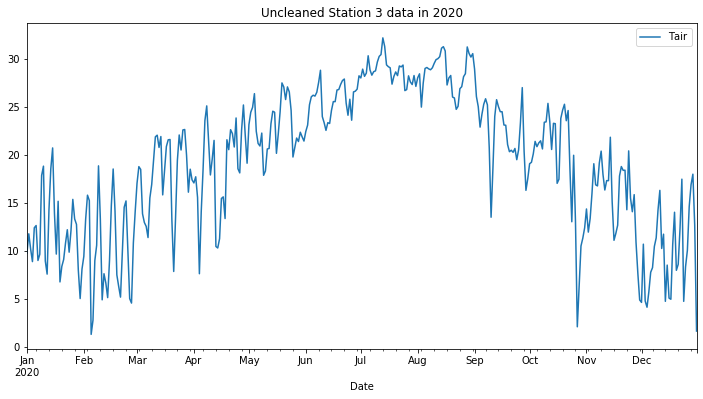

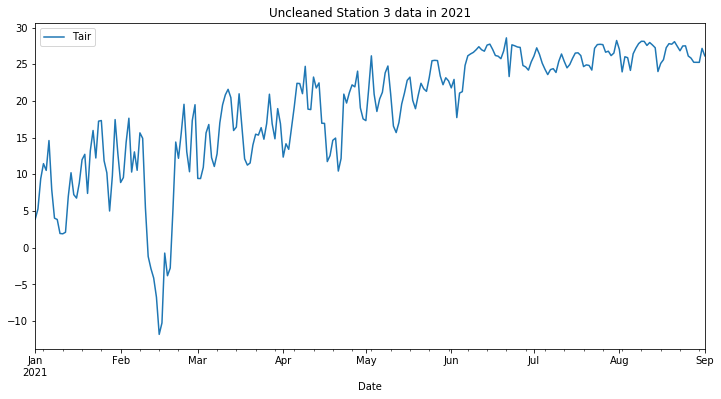

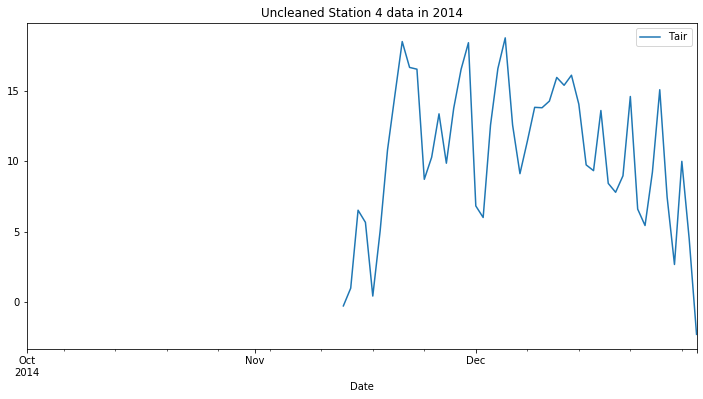

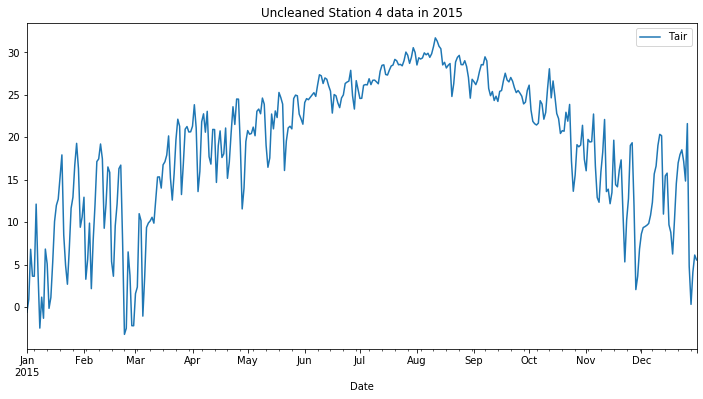

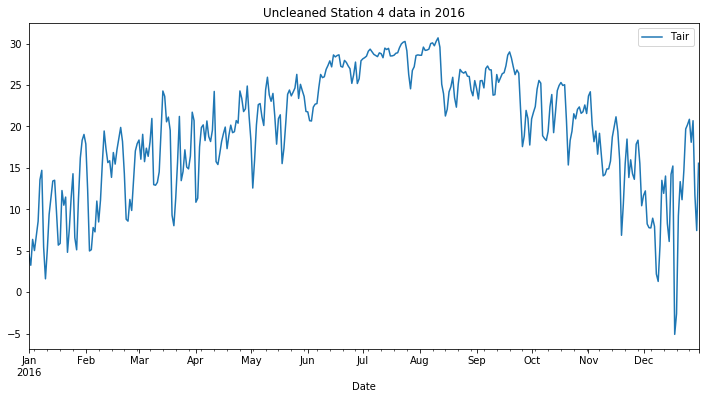

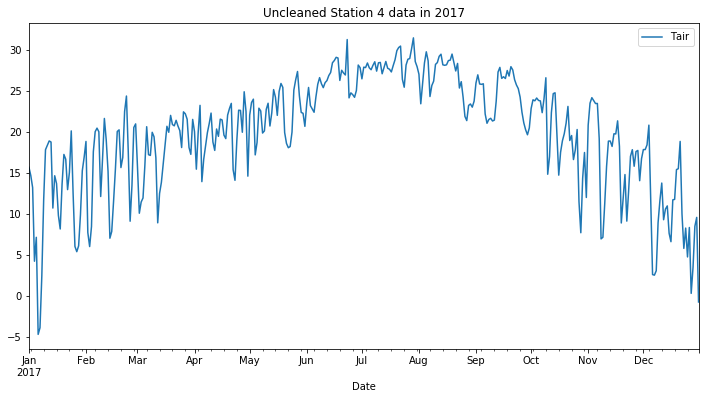

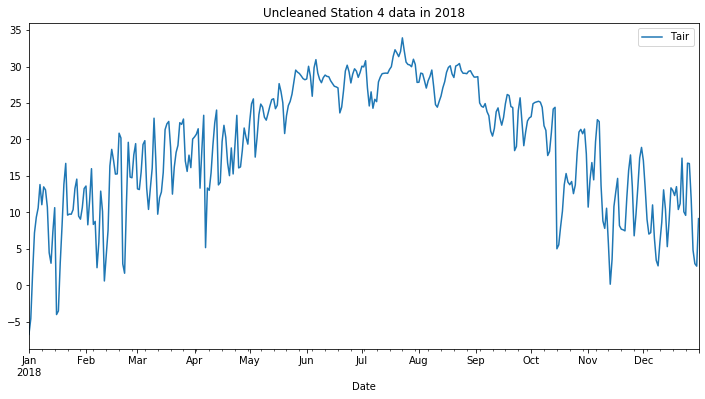

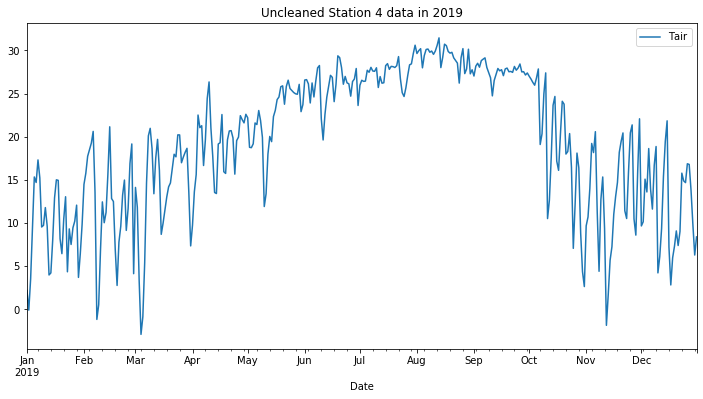

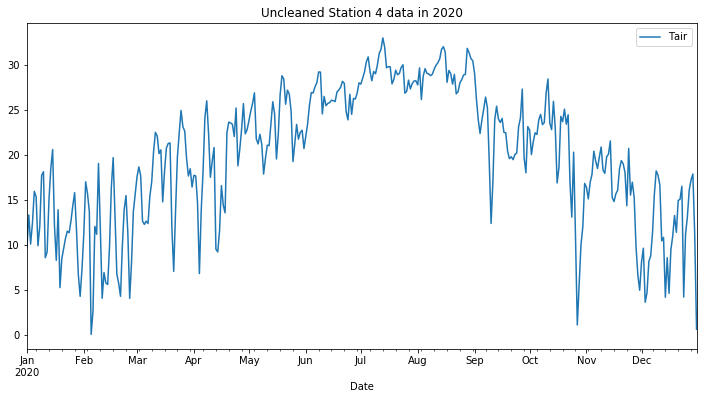

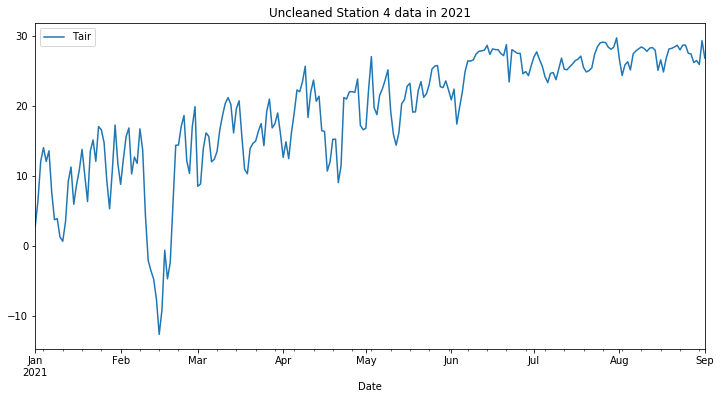

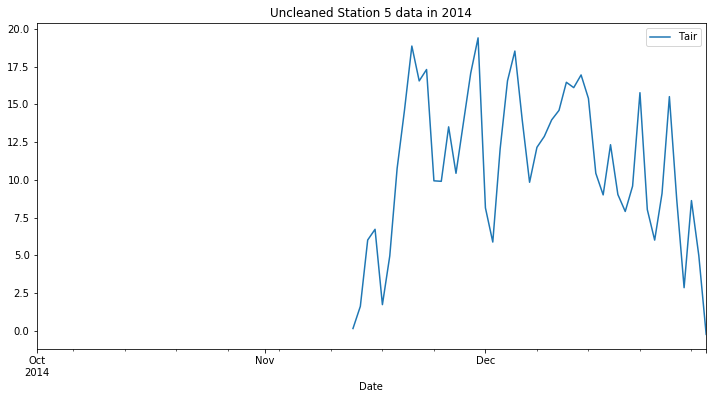

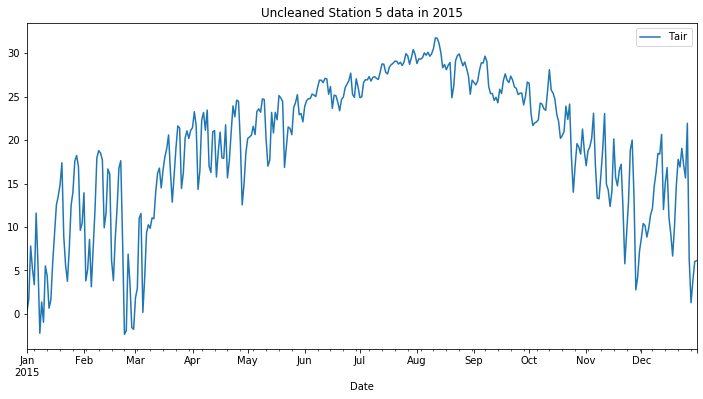

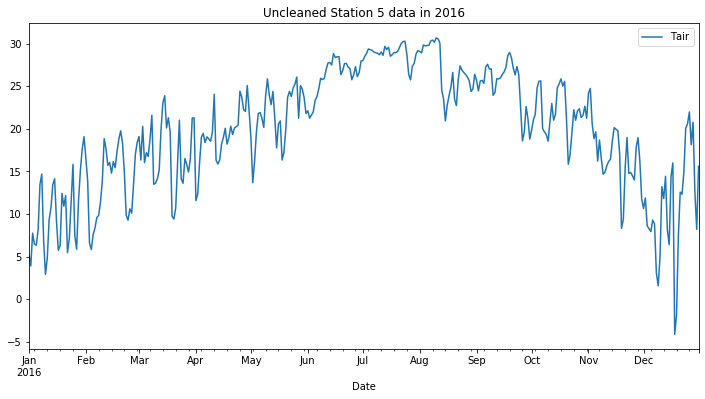

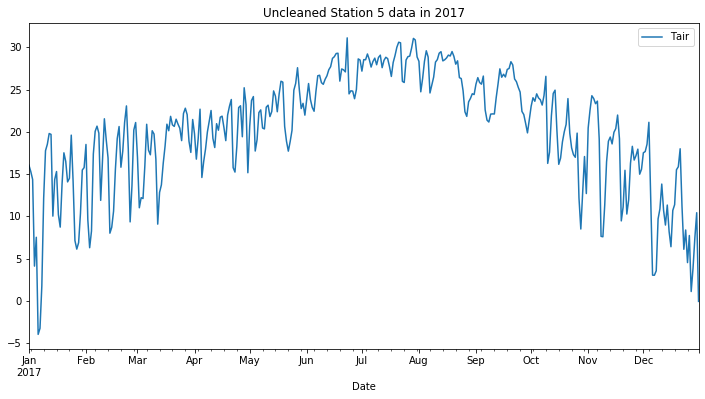

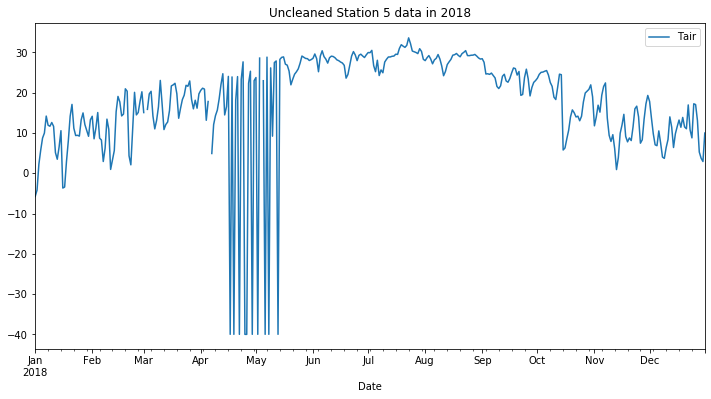

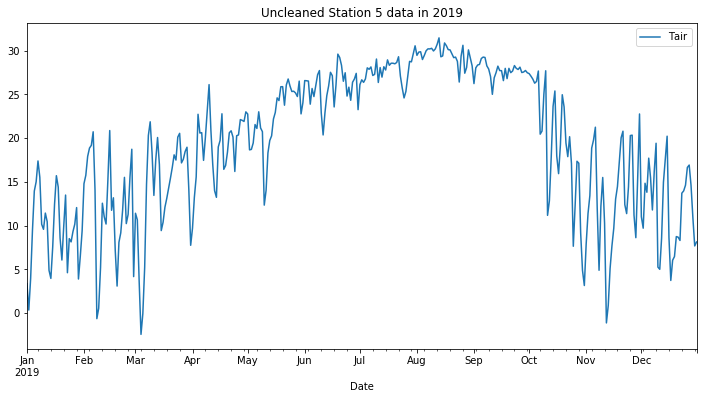

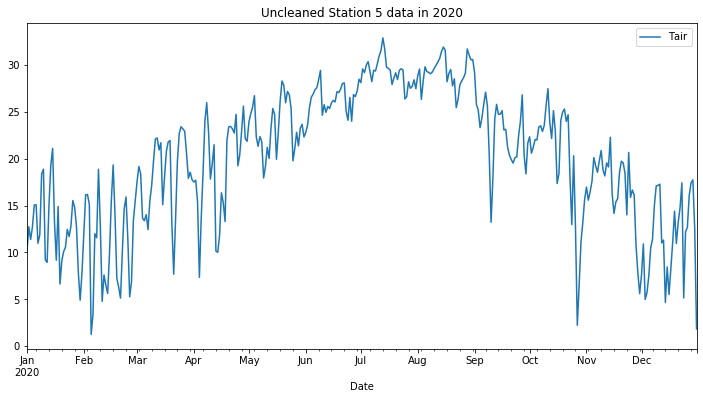

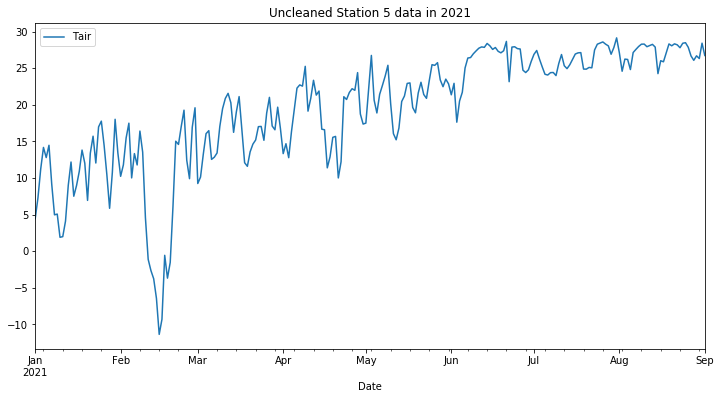

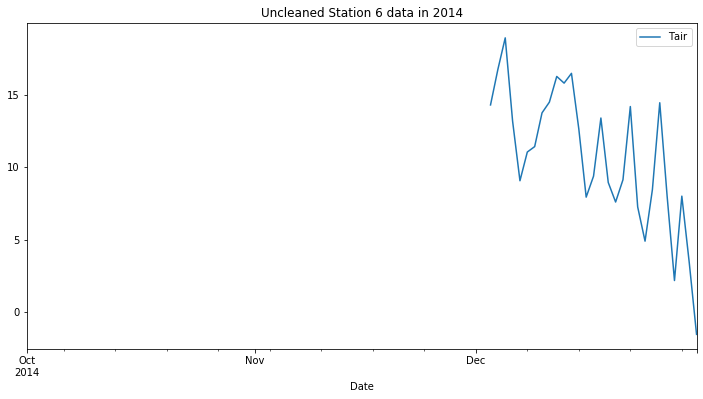

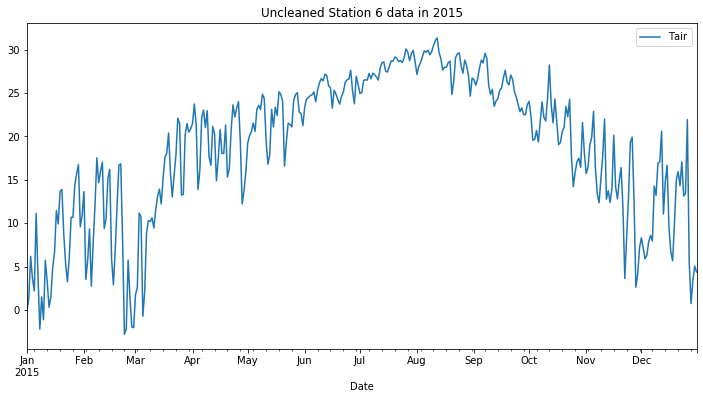

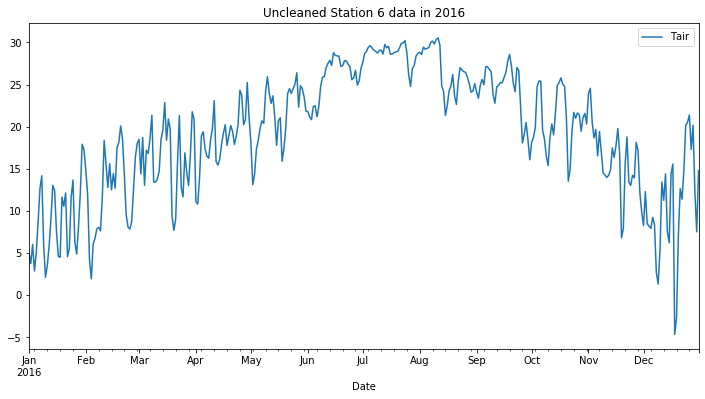

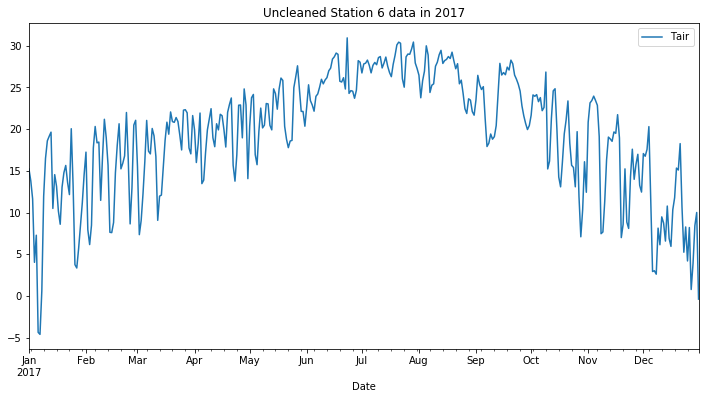

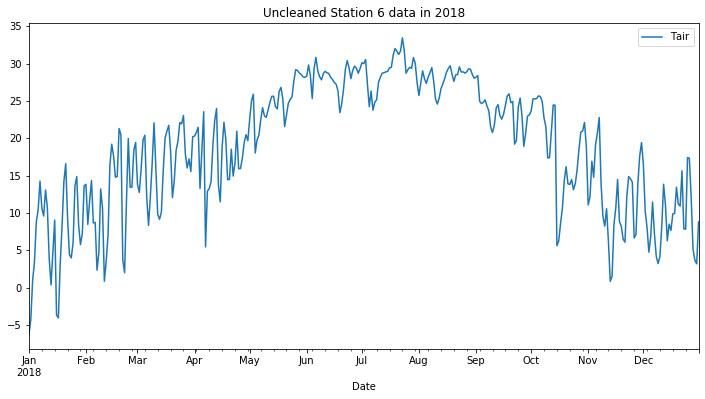

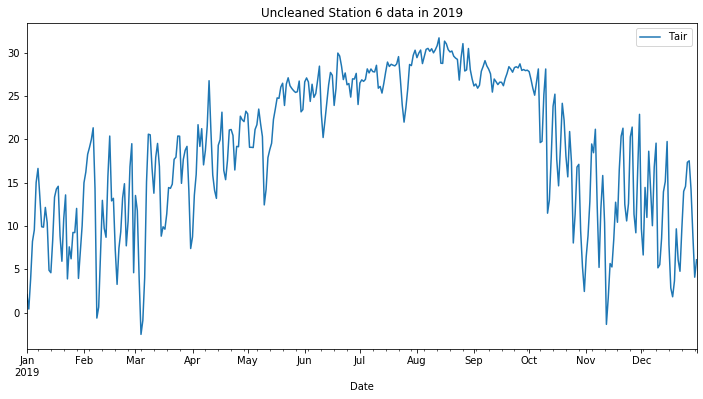

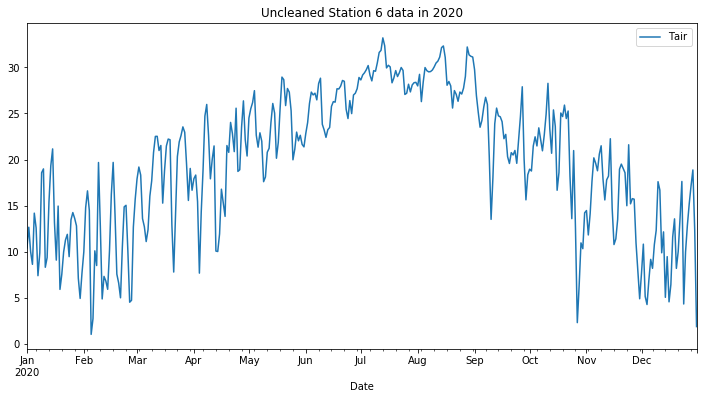

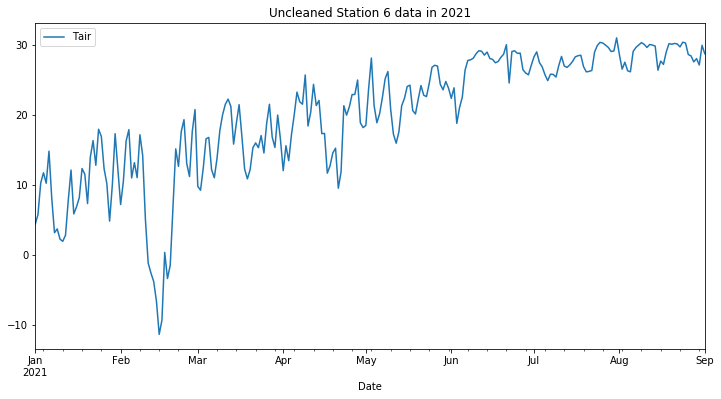

In [5]:
# plot the Tair content for the uncleaned met data (all stations & all years)
years = [str(item) for item in range(2014, 2022)]
station = 0

#Iterate over each station's uncleaned df
for unclean in met_list :
    #This is the station whose data we are working with in this iteration of the loop
    station += 1
    #Plot Tair data for all available years
    for i in years:
        unclean.loc[i].resample('D').mean().plot(figsize=(12,6), y=["Tair"])
        plt.title("Uncleaned Station " + str(station) + " data in " + i)
        plt.show()

These are the date ranges for the raw met data for all the stations:

- Station 1: 2014-10-01 to 2021-09-01
- Station 2: 2014-10-02 13:00:00 to 2021-06-06 13:00:00
- Station 3: 2014-11-12 11:00:00 to 2021-09-01
- Station 4: 2014-11-13 12:00:00 to 2021-09-01
- Station 5: 2014-11-13 17:00:00 to 2021-09-01
- Station 6: 2014-12-03 17:00:00 to 2021-09-01

In [6]:
#remove extraneous NaN rows from station 2 met data
station_2 = met_list[1].loc['2014-10-02 13:00:00':'2021-06-06 13:00:00']
met_list[1] = station_2
#remove extraneous NaN rows from station 3 met data
station_3 = met_list[2].loc['2014-11-12 11:00:00':]
met_list[2] = station_3
#remove extraneous NaN rows from station 4 met data
station_4 = met_list[3].loc['2014-11-13 12:00:00':]
met_list[3] = station_4
#remove extraneous NaN rows from station 5 met data
station_5 = met_list[4].loc['2014-11-13 17:00:00':]
met_list[4] = station_5
#remove extraneous NaN rows from station 6 met data
station_6 = met_list[5].loc['2014-12-03 17:00:00':]
met_list[5] = station_6

In [7]:
# merge the soil and met dataframes into one big dataframe per station
merge_list = []
for soil_df, met_df in zip(soil_list, met_list) :
    merge_df = pd.merge(soil_df, met_df, on=["Date"], how='inner')
    merge_list.append(merge_df)

# len of list should be 6 (for the 6 stations)
print(len(merge_list))

6


In [8]:
# save merged station data locally (for use in Colab)
for index in range(0, 6) :
    merge_list[index].to_csv('merged_' + str((index + 1)) + '.dat')

Below, I will calculate the percentage of missing data per attribute for each type of dataset and for each station. Essentially, I am dividing the total number of NA entries per attribute by the number of entries in the dataset (then multiplying by 100) to get this percent number.

In [9]:
soil_percent = []
met_percent = []
station_percent = []

# go through each station's soil df
for soil_df in soil_list :
    # find the total number of NA entries per column
    null_df = soil_df.isnull().sum()
    rows = len(soil_df.index)
    # find percent of NA entries per column
    null_df = (null_df / rows) * 100
    soil_percent.append(null_df)
    
# go through each station's met df
for met_df in met_list :
    # find the total number of NA entries per column
    null_df = met_df.isnull().sum()
    rows = len(met_df.index)
    # find percent of NA entries per column
    null_df = (null_df / rows) * 100
    met_percent.append(null_df)
    
# go through each station's merged df
for merged_df in merge_list :
    # find the total number of NA entries per column
    null_df = merged_df.isnull().sum()
    rows = len(merged_df.index)
    # find percent of NA entries per column
    null_df = (null_df / rows) * 100
    station_percent.append(null_df)

# print out all percentage dfs (contain percent missing data per attribute)
station = 0
for soil_df, met_df, merged_df in zip(soil_percent, met_percent, station_percent) :
    station += 1
    print('Percent Missing Soil Data Per Attribute in Station ' + str(station))
    print(soil_df)
    print()
    print('Percent Missing Met Data Per Attribute in Station ' + str(station))
    print(met_df)
    print()
    print('Percent Missing Total Data Per Attribute in Station ' + str(station))
    print(merged_df)
    print()

Percent Missing Soil Data Per Attribute in Station 1
Ppt       0.983756
SWC_5     1.091936
SWC_10    1.005730
SWC_20    1.338720
SWC_50    1.026014
T_5       0.983756
T_10      0.983756
T_20      0.983756
T_50      0.983756
Flag      0.000000
dtype: float64

Percent Missing Met Data Per Attribute in Station 1
Ppt              0.961269
Tair             0.969513
RH               0.961269
Windspeed        0.961269
Winddirection    0.961269
Srad             0.961269
dtype: float64

Percent Missing Total Data Per Attribute in Station 1
Ppt_x            0.995876
SWC_5            1.105388
SWC_10           1.018121
SWC_20           1.355213
SWC_50           1.038654
T_5              0.995876
T_10             0.995876
T_20             0.995876
T_50             0.995876
Flag             0.000000
Ppt_y            0.997587
Tair             1.006143
RH               0.997587
Windspeed        0.997587
Winddirection    0.997587
Srad             0.997587
dtype: float64

Percent Missing Soil Data Per A

Below are the date ranges for each type of dataset (soil, met, soil+met merged) per station. If you notice, the soil and met time ranges don't align together. Thus, when making the merged datasets, I only included the values where the time ranges overlap between soil and met datasets, and left out the extra values at the beginning of the met dataset and at the end of the soil dataset. This ensures that the each of the merged datasets don't have unneccessary null values at the beginning and end of the dataset.

In [10]:
print('Max Date Ranges For Soil Data Per Station:\n')
print('Station 1: 2015-01-01 00:00:00 to 2021-10-01 00:00:00\nStation 2: 2015-01-01 00:00:00 to 2021-06-06 13:00:00\nStation 3: 2015-01-01 00:00:00 to 2021-10-01 00:00:00\nStation 4: 2015-01-01 00:00:00 to 2021-10-01 00:00:00\nStation 5: 2015-01-01 00:00:00 to 2021-10-01 00:00:00\nStation 6: 2015-01-01 00:00:00 to 2021-10-01 00:00:00\n')
print('Max Date Ranges For Met Data Per Station:\n')
print('Station 1: 2014-10-01 00:00:00 to 2021-09-01 00:00:00\nStation 2: 2014-10-02 13:00:00 to 2021-06-06 13:00:00\nStation 3: 2014-11-12 11:00:00 to 2021-09-01 00:00:00\nStation 4: 2014-11-13 12:00:00 to 2021-09-01 00:00:00\nStation 5: 2014-11-13 17:00:00 to 2021-09-01 00:00:00\nStation 6: 2014-12-03 17:00:00 to 2021-09-01 00:00:00\n')
print('Max Date Ranges For Merged Data Per Station:\n')
print('Station 1: 2015-01-01 00:00:00 to 2021-09-01 00:00:00\nStation 2: 2015-01-01 00:00:00 to 2021-06-06 13:00:00\nStation 3: 2015-01-01 00:00:00 to 2021-09-01 00:00:00\nStation 4: 2015-01-01 00:00:00 to 2021-09-01 00:00:00\nStation 5: 2015-01-01 00:00:00 to 2021-09-01 00:00:00\nStation 6: 2015-01-01 00:00:00 to 2021-09-01 00:00:00\n')

Max Date Ranges For Soil Data Per Station:

Station 1: 2015-01-01 00:00:00 to 2021-10-01 00:00:00
Station 2: 2015-01-01 00:00:00 to 2021-06-06 13:00:00
Station 3: 2015-01-01 00:00:00 to 2021-10-01 00:00:00
Station 4: 2015-01-01 00:00:00 to 2021-10-01 00:00:00
Station 5: 2015-01-01 00:00:00 to 2021-10-01 00:00:00
Station 6: 2015-01-01 00:00:00 to 2021-10-01 00:00:00

Max Date Ranges For Met Data Per Station:

Station 1: 2014-10-01 00:00:00 to 2021-09-01 00:00:00
Station 2: 2014-10-02 13:00:00 to 2021-06-06 13:00:00
Station 3: 2014-11-12 11:00:00 to 2021-09-01 00:00:00
Station 4: 2014-11-13 12:00:00 to 2021-09-01 00:00:00
Station 5: 2014-11-13 17:00:00 to 2021-09-01 00:00:00
Station 6: 2014-12-03 17:00:00 to 2021-09-01 00:00:00

Max Date Ranges For Merged Data Per Station:

Station 1: 2015-01-01 00:00:00 to 2021-09-01 00:00:00
Station 2: 2015-01-01 00:00:00 to 2021-06-06 13:00:00
Station 3: 2015-01-01 00:00:00 to 2021-09-01 00:00:00
Station 4: 2015-01-01 00:00:00 to 2021-09-01 00:00:00
S